# 04 — Итоговый отчёт

Задача: оценить, насколько хорошо мы поймали ботоферм против ground truth.

In [1]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
sns.set_theme(style='whitegrid')

from src.evaluation import evaluate, cluster_recovery

predictions = pd.read_csv('../data/processed/predictions.csv', index_col='user_id')


## Сводные метрики

In [2]:
metrics = evaluate(predictions)
rows = []
for method, m in metrics.items():
    rows.append({'method': method, **m})
summary = pd.DataFrame(rows).set_index('method')
summary.round(3)


,precision,recall,f1,tp,fp,fn,tn
method,,,,,,,
combined,0.856,1.000,0.922,160,27,0,1973
dbscan_only,0.325,0.081,0.130,13,27,147,1973
louvain_only,1.000,1.000,1.000,160,0,0,2000


## Матрицы ошибок

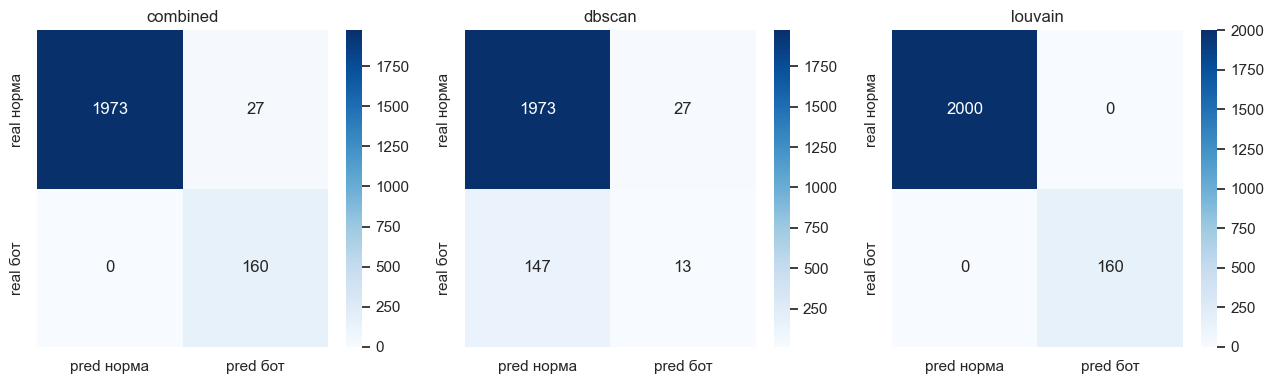

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (method, col) in zip(axes, [('combined','bot_candidate'),
                                     ('dbscan','in_dbscan_cluster'),
                                     ('louvain','in_suspicious_community')]):
    cm = confusion_matrix(predictions.is_bot, predictions[col])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['pred норма','pred бот'], yticklabels=['real норма','real бот'])
    ax.set_title(method)
plt.tight_layout(); plt.show()


## Покрытие ферм

In [4]:
cluster_recovery(predictions).style.background_gradient(subset=['recall_in_cluster','dominant_share'])


,bot_cluster_id,size,recall_in_cluster,n_louvain_communities,dominant_community,dominant_share
0,0,26,1.000000,1,0,1.000000
1,1,47,1.000000,1,1,1.000000
2,2,30,1.000000,1,2,1.000000
3,3,31,1.000000,1,3,1.000000
4,4,26,1.000000,1,4,1.000000


## Выводы

**1. Louvain победил DBSCAN с разгромным счётом.**
На наших данных бот-сигнал в первую очередь *структурный* (кольцевые подписки, общие IP), а не *градиентный по фичам*. Louvain находит сообщества из плотных связей естественно, DBSCAN же требует, чтобы боты сидели плотным облаком в фиче-пространстве — а они сидят, но **рядом сидит и нормальная масса**, и DBSCAN либо сливает их в один кластер, либо ловит крошечные очаги.

**2. Combined-метрика хуже Louvain в одиночку.**
Объединение двух методов через OR подняло Recall до 1.0, но снизило Precision (≈0.86): DBSCAN добавил FP без новых TP. Урок: **ансамбль через OR не всегда хорош** — иногда слабый член только шумит.

**3. Все 5 ферм идеально склеились в свои Louvain-сообщества** (`dominant_share=1.0`). В реальной задаче такого не будет — настоящие боты сильнее маскируются — но это показывает, что метод чувствителен к внутренней связности фермы (взаимные подписки, общие подсети).

## Что улучшать

- Сейчас сигнал слишком сильный: фермы 100% подписаны друг на друга. Нужно усложнить генератор (доля колец 30-50%) и посмотреть, где Louvain ломается.
- Добавить semi-supervised: ручную разметку топ-10 подозрительных и обучить классификатор (catboost/xgb) на этих метках с фичами.
- Вместо OR — мета-классификатор поверх предсказаний обоих методов.
- На реальных данных вместо `is_bot` использовать **прокси-метку**: жалобы, баны модерации, исчезнувшие аккаунты — и валидировать всё на отложенной выборке.

## Что показать на собеседовании

1. Воспроизводимый pipeline: `python -m src.generator → features → detection → evaluation`.
2. Один график на каждый признак из устного ответа (есть в `01_eda.ipynb`).
3. Историю про **парадокс CV** — наивная гипотеза проверена и сломалась, проблема разобрана, замена найдена. Это лучший сигнал зрелости аналитика.
4. Историю про **DBSCAN vs Louvain** — выбор метода обоснован эмпирически, а не по моде.